 # Era Boundary Detection — Method Comparison



 This notebook tests three different approaches for detecting era boundaries on

 the matrix profile signal. The goal is to find the best method to replace the

 naive zero-crossing approach before bringing it back into the main analysis.



 All three methods share the same problem: the raw MP signal is noisy, and we

 want boundaries that represent *sustained* regime shifts, not momentary spikes.



 **Methods tested:**

 1. **EMA Crossover** — fast/slow exponential moving average crossover. A boundary

    fires when the short-term trend crosses the long-term trend and stays crossed.

 2. **Bollinger Band Breakout** — a boundary fires when the signal escapes the

    rolling mean ± N·std envelope and *stays* outside for a minimum number of videos.

 3. **CUSUM** — cumulative sum change detection. Accumulates deviations from a

    baseline and fires when the evidence for a shift exceeds a threshold. Resets

    after each detection.

In [17]:
import sys
import re
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sqlalchemy import func

sys.path.insert(0, '.')
from models import Session, Video, TranscriptChunk, Channel

import stumpy
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize

plt.rcParams['figure.dpi'] = 120


 ## Config

In [18]:
CHANNEL_QUERY   = 'healthygamergg'
SHORTS_MAX_SECS = 180
PCA_DIMS        = 10
MP_WINDOW       = 25
SMOOTH_WINDOW   = 35   # pre-smoothing applied before all three methods

# --- Method 1: EMA Crossover ---
EMA_FAST        = 15   # fast EMA window (videos) — ~5 weeks
EMA_SLOW        = 75   # slow EMA window (videos) — ~18 weeks
EMA_MIN_SEP     = 40   # min videos between two crossover boundaries

# --- Method 2: Bollinger Band Breakout ---
BB_WINDOW       = 30   # rolling mean/std window (videos) — ~15 weeks
BB_N_STD        = .75  # band width in standard deviations (try 0.75–1.5)
BB_CONFIRM      = 20   # videos signal must stay outside band to confirm a new era
BB_MIN_SEP      = 40   # min videos between two Bollinger boundaries

# --- Method 3: CUSUM ---
CUSUM_THRESHOLD = 6.0  # accumulated deviation needed to trigger a boundary (try 2–5)
CUSUM_DRIFT     = 0.5  # allowance subtracted each step — controls sensitivity to drift
CUSUM_MIN_SEP   = 40   # min videos between two CUSUM boundaries


 ## Load Data

 Using the ORM — no raw SQL needed.

In [19]:
session = Session()

# Mean-pool embeddings per video, long-form only, sorted by date
rows = (
    session.query(
        Video.video_id,
        Video.title,
        Video.published_at,
        func.avg(TranscriptChunk.embedding).label('mean_embedding'),
    )
    .join(TranscriptChunk, Video.video_id == TranscriptChunk.video_id)
    .join(Channel, Video.channel_id == Channel.channel_id)
    .filter(Channel.title.ilike(f'%{CHANNEL_QUERY}%'))
    .filter(TranscriptChunk.embedding.isnot(None))
    .filter(Video.duration_seconds > SHORTS_MAX_SECS)
    .group_by(Video.video_id, Video.title, Video.published_at)
    .order_by(Video.published_at)
    .all()
)

session.close()

df = pd.DataFrame(rows, columns=['video_id', 'title', 'published_at', 'mean_embedding'])
df['published_at'] = pd.to_datetime(df['published_at'], utc=True)

def _parse_emb(v):
    if isinstance(v, np.ndarray):
        return v.astype(float)
    if isinstance(v, (list, tuple)):
        return np.array(v, dtype=float)
    nums = re.findall(r'[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?', str(v))
    return np.array(nums, dtype=float)

df['embedding'] = df['mean_embedding'].apply(_parse_emb)
emb      = np.stack(df['embedding'].values)
emb_norm = normalize(emb)

pca     = PCA(n_components=PCA_DIMS, random_state=42)
emb_pca = pca.fit_transform(emb_norm)

print(f'Loaded {len(df)} videos')


Loaded 1021 videos


 ## Build the MP Signal

 Same weighted multi-dimensional matrix profile as the main notebook.

In [20]:
print('Computing matrix profiles...')
weights     = pca.explained_variance_ratio_ / pca.explained_variance_ratio_.sum()
n_profile   = len(df) - MP_WINDOW + 1
mp_combined = np.zeros(n_profile)

for dim in range(PCA_DIMS):
    mp_dim       = stumpy.stump(emb_pca[:, dim].astype(np.float64), m=MP_WINDOW)[:, 0].astype(float)
    mp_combined += weights[dim] * mp_dim

mp_z     = (mp_combined - mp_combined.mean()) / (mp_combined.std() + 1e-10)
mp_dates = df['published_at'].values[:n_profile]

# Pre-smooth before passing to all three methods
mp_smooth = pd.Series(mp_z).rolling(SMOOTH_WINDOW, center=True, min_periods=1).mean().values
mp_smooth = (mp_smooth - mp_smooth.mean()) / (mp_smooth.std() + 1e-10)

print('Done.')


Computing matrix profiles...
Done.


 ## Method 1 — EMA Crossover



 Two exponential moving averages: a **fast** one (short window, responds quickly)

 and a **slow** one (long window, represents the established trend).



 A boundary is detected wherever the fast EMA crosses the slow EMA —

 i.e. the short-term content trend has overtaken the long-term baseline.

 Because the slow EMA requires sustained movement to shift, a single noisy spike

 won't trigger a crossing; both lines have to agree a shift happened.



 **Tuning:**

 - `EMA_FAST` — how quickly the signal responds. Smaller = more sensitive.

 - `EMA_SLOW` — the long-term baseline. Larger = only catches major, sustained shifts.

 - The ratio EMA_FAST / EMA_SLOW controls selectivity. A ratio of ~0.3 is a good start.

 - `EMA_MIN_SEP` — merges crossings that happen too close together.

EMA crossover: 12 boundaries  (fast=15, slow=75, min_sep=40)
  2019-01-25
  2019-11-21
  2020-06-24
  2021-05-10
  2021-09-18
  2021-12-13
  2022-05-10
  2022-08-15
  2023-08-14
  2024-03-01
  2025-03-29
  2025-08-15


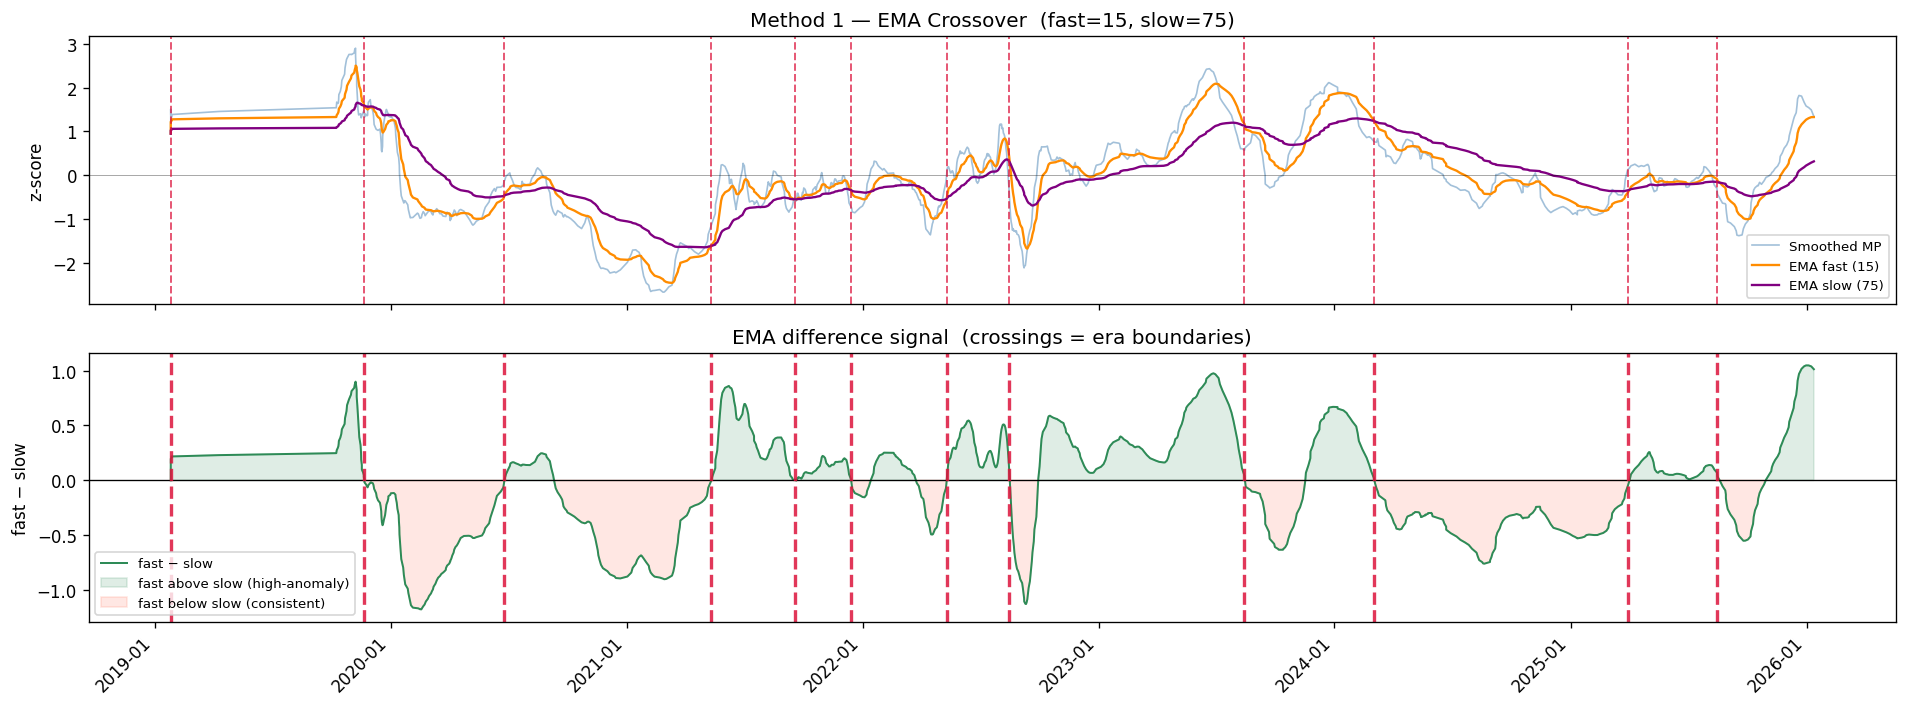

In [21]:
_s = pd.Series(mp_smooth)
ema_fast = _s.ewm(span=EMA_FAST, adjust=False).mean().values
ema_slow = _s.ewm(span=EMA_SLOW, adjust=False).mean().values

# Crossover = sign change in (fast - slow)
diff       = ema_fast - ema_slow
cross_sign = np.sign(diff)
raw_cross  = np.where(np.diff(cross_sign) != 0)[0]

# Enforce minimum separation
ema_boundaries = []
for idx in raw_cross:
    if not ema_boundaries or (idx - ema_boundaries[-1]) >= EMA_MIN_SEP:
        ema_boundaries.append(int(idx))

print(f'EMA crossover: {len(ema_boundaries)} boundaries  '
      f'(fast={EMA_FAST}, slow={EMA_SLOW}, min_sep={EMA_MIN_SEP})')
for b in ema_boundaries:
    print(f'  {pd.Timestamp(mp_dates[b]).date()}')

fig, axes = plt.subplots(2, 1, figsize=(16, 6), sharex=True)

axes[0].plot(mp_dates, mp_smooth, lw=1.0, color='steelblue', alpha=0.5, label='Smoothed MP')
axes[0].plot(mp_dates, ema_fast, lw=1.4, color='darkorange', label=f'EMA fast ({EMA_FAST})')
axes[0].plot(mp_dates, ema_slow, lw=1.4, color='purple',     label=f'EMA slow ({EMA_SLOW})')
axes[0].axhline(0, color='k', lw=0.5, alpha=0.4)
for b in ema_boundaries:
    axes[0].axvline(mp_dates[b], color='crimson', lw=1.2, ls='--', alpha=0.7)
axes[0].set_title(f'Method 1 — EMA Crossover  (fast={EMA_FAST}, slow={EMA_SLOW})')
axes[0].set_ylabel('z-score')
axes[0].legend(fontsize=8)

axes[1].plot(mp_dates, diff, lw=1.2, color='seagreen', label='fast − slow')
axes[1].axhline(0, color='k', lw=0.8)
axes[1].fill_between(mp_dates, diff, 0, where=diff > 0, alpha=0.15, color='seagreen',
                     label='fast above slow (high-anomaly)')
axes[1].fill_between(mp_dates, diff, 0, where=diff < 0, alpha=0.15, color='tomato',
                     label='fast below slow (consistent)')
for b in ema_boundaries:
    axes[1].axvline(mp_dates[b], color='crimson', lw=2, ls='--', alpha=0.85)
axes[1].set_title('EMA difference signal  (crossings = era boundaries)')
axes[1].set_ylabel('fast − slow')
axes[1].legend(fontsize=8)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('boundary_ema.png', bbox_inches='tight')
plt.show()


 ## Method 2 — Bollinger Band Breakout



 Compute a rolling mean and rolling standard deviation of the smoothed MP signal.

 The "band" is mean ± `BB_N_STD` · std. When the signal exits this band it has

 moved unusually far from its recent baseline.



 Unlike zero crossings, a boundary only fires after the signal has stayed *outside*

 the band for `BB_CONFIRM` consecutive videos — this is the "confirmation" window

 that filters out brief spikes. The era starts at the point the signal first broke

 out, not when it's confirmed.



 **Tuning:**

 - `BB_WINDOW` — lookback for the rolling baseline. Longer = band moves more slowly.

 - `BB_N_STD` — band width. 1.0 = fairly sensitive; 1.5–2.0 = only large breaks.

 - `BB_CONFIRM` — confirmation window. Higher = fewer false positives, may miss fast breaks.

Bollinger breakout: 10 boundaries  (window=30, n_std=0.75, confirm=20)
  2019-10-24
  2019-12-16
  2021-01-07
  2021-06-28
  2021-12-10
  2022-05-23
  2022-07-21
  2024-03-20
  2024-07-31
  2025-03-29


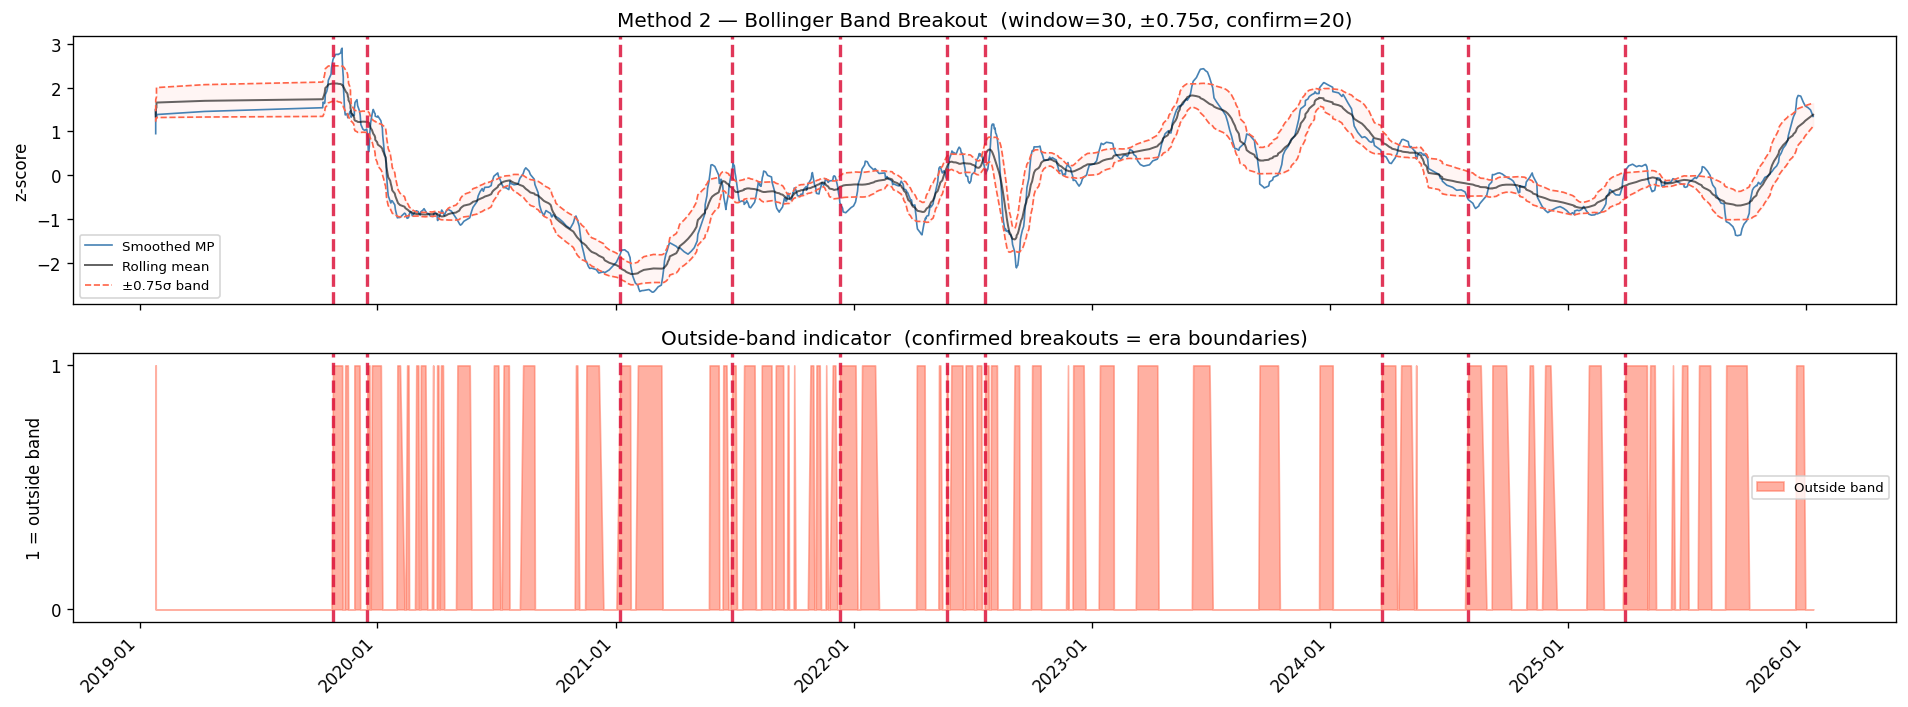

In [22]:
_s       = pd.Series(mp_smooth)
bb_mean  = _s.rolling(BB_WINDOW, center=True, min_periods=1).mean().values
bb_std   = _s.rolling(BB_WINDOW, center=True, min_periods=1).std().fillna(0).values
bb_upper = bb_mean + BB_N_STD * bb_std
bb_lower = bb_mean - BB_N_STD * bb_std

outside  = (mp_smooth > bb_upper) | (mp_smooth < bb_lower)

# Find breakout starts: first video outside band after being inside, confirmed by BB_CONFIRM
bb_boundaries = []
i = 0
while i < len(outside):
    if outside[i]:
        # Check if it stays outside for BB_CONFIRM videos
        end = min(i + BB_CONFIRM, len(outside))
        if outside[i:end].sum() >= BB_CONFIRM * 0.7:  # 70% must be outside
            if not bb_boundaries or (i - bb_boundaries[-1]) >= BB_MIN_SEP:
                bb_boundaries.append(i)
            i += BB_MIN_SEP  # skip ahead to avoid double-counting
            continue
    i += 1

print(f'Bollinger breakout: {len(bb_boundaries)} boundaries  '
      f'(window={BB_WINDOW}, n_std={BB_N_STD}, confirm={BB_CONFIRM})')
for b in bb_boundaries:
    print(f'  {pd.Timestamp(mp_dates[b]).date()}')

fig, axes = plt.subplots(2, 1, figsize=(16, 6), sharex=True)

axes[0].plot(mp_dates, mp_smooth, lw=1.0, color='steelblue', label='Smoothed MP')
axes[0].plot(mp_dates, bb_mean,  lw=1.2, color='k',        alpha=0.6, label='Rolling mean')
axes[0].plot(mp_dates, bb_upper, lw=1.0, color='tomato',   ls='--',   label=f'±{BB_N_STD}σ band')
axes[0].plot(mp_dates, bb_lower, lw=1.0, color='tomato',   ls='--')
axes[0].fill_between(mp_dates, bb_lower, bb_upper, alpha=0.06, color='tomato')
for b in bb_boundaries:
    axes[0].axvline(mp_dates[b], color='crimson', lw=2, ls='--', alpha=0.85)
axes[0].set_title(f'Method 2 — Bollinger Band Breakout  '
                  f'(window={BB_WINDOW}, ±{BB_N_STD}σ, confirm={BB_CONFIRM})')
axes[0].set_ylabel('z-score')
axes[0].legend(fontsize=8)

axes[1].plot(mp_dates, outside.astype(float), lw=0, color='tomato')
axes[1].fill_between(mp_dates, outside.astype(float), 0, color='tomato', alpha=0.5,
                     label='Outside band')
for b in bb_boundaries:
    axes[1].axvline(mp_dates[b], color='crimson', lw=2, ls='--', alpha=0.85)
axes[1].set_title('Outside-band indicator  (confirmed breakouts = era boundaries)')
axes[1].set_ylabel('1 = outside band')
axes[1].set_yticks([0, 1])
axes[1].legend(fontsize=8)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('boundary_bollinger.png', bbox_inches='tight')
plt.show()


 ## Method 3 — CUSUM (Cumulative Sum)



 CUSUM was originally designed for quality control: "has the mean of this process

 shifted from its baseline?" It works by accumulating evidence for an upward or

 downward shift separately, and triggering when the accumulated evidence exceeds

 a threshold.



 Two counters run in parallel:

 - `S_pos` accumulates evidence for an *upward* shift (high-anomaly regime)

 - `S_neg` accumulates evidence for a *downward* shift (consistent regime)



 Each step, if the signal deviates by more than `CUSUM_DRIFT` from zero, the

 appropriate counter grows. Otherwise it decays toward zero. A boundary fires when

 either counter exceeds `CUSUM_THRESHOLD`. Both counters reset after detection.



 **Tuning:**

 - `CUSUM_THRESHOLD` — sensitivity. Lower = fires sooner. Try 2–6.

 - `CUSUM_DRIFT` — how much deviation to ignore per step. Higher = only catches

   large sustained moves. Try 0.3–1.0.

 - `CUSUM_MIN_SEP` — prevents double-firing immediately after a detection.

CUSUM: 11 boundaries  (threshold=6.0, drift=0.5)
  2019-01-25
  2019-11-21
  2020-02-24
  2020-10-16
  2021-03-15
  2022-04-16
  2022-08-10
  2023-05-09
  2023-11-24
  2025-02-10
  2025-09-22


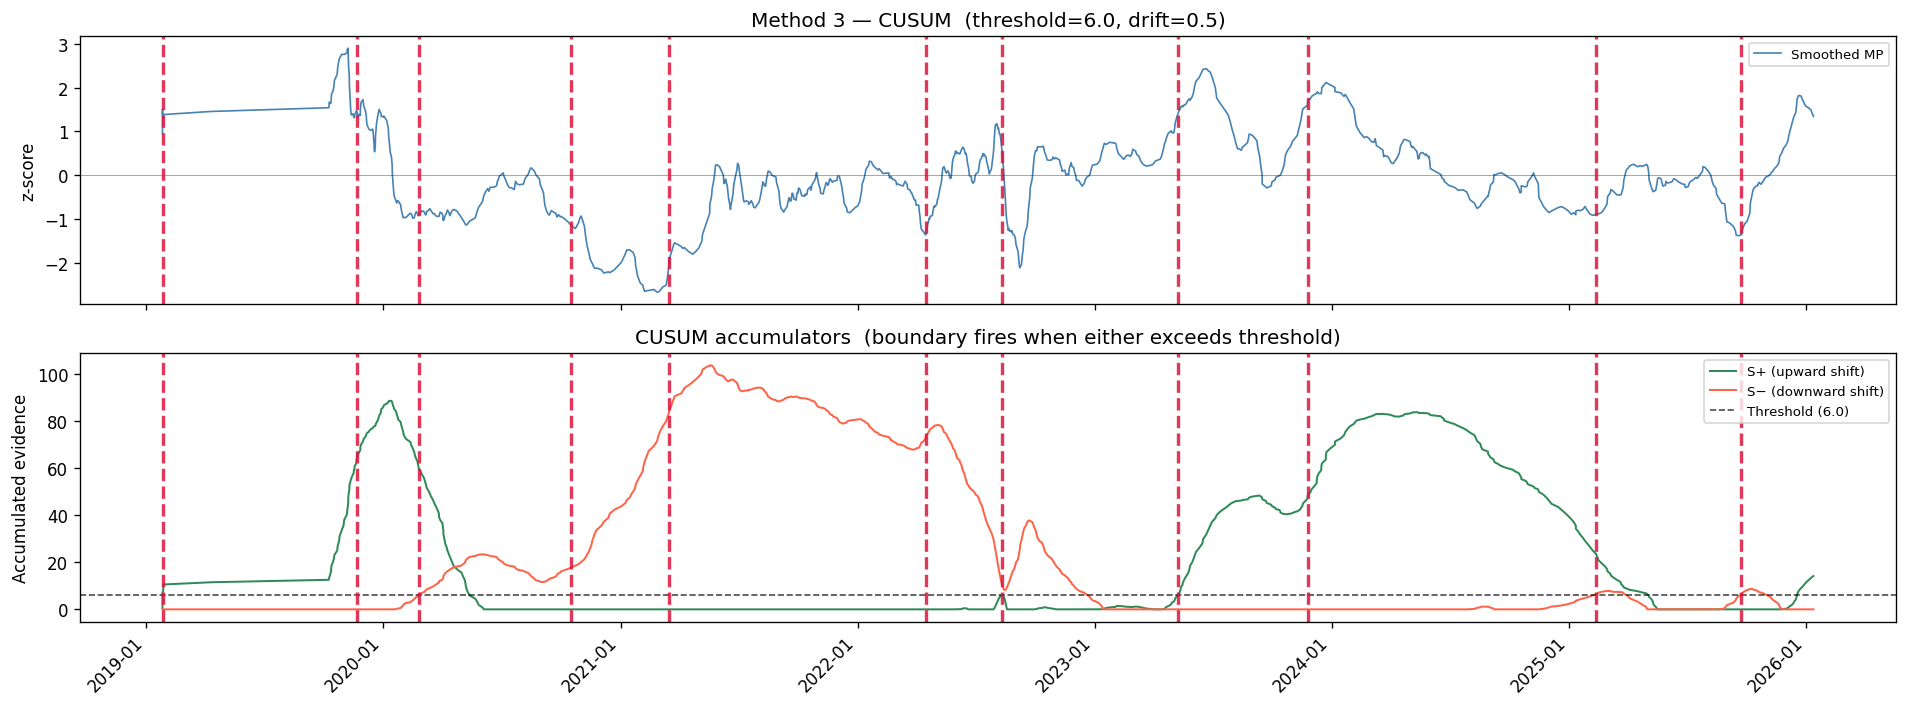

In [23]:
S_pos = 0.0
S_neg = 0.0
cusum_boundaries = []
last_detection   = -CUSUM_MIN_SEP

for i, x in enumerate(mp_smooth):
    S_pos = max(0, S_pos + x - CUSUM_DRIFT)
    S_neg = max(0, S_neg - x - CUSUM_DRIFT)

    if (S_pos > CUSUM_THRESHOLD or S_neg > CUSUM_THRESHOLD):
        if (i - last_detection) >= CUSUM_MIN_SEP:
            cusum_boundaries.append(i)
            last_detection = i
        S_pos = 0.0
        S_neg = 0.0

# Build cumulative traces for visualisation (recompute without resets for the plot)
S_pos_trace = np.zeros(len(mp_smooth))
S_neg_trace = np.zeros(len(mp_smooth))
sp, sn = 0.0, 0.0
for i, x in enumerate(mp_smooth):
    sp = max(0, sp + x - CUSUM_DRIFT)
    sn = max(0, sn - x - CUSUM_DRIFT)
    S_pos_trace[i] = sp
    S_neg_trace[i] = sn

print(f'CUSUM: {len(cusum_boundaries)} boundaries  '
      f'(threshold={CUSUM_THRESHOLD}, drift={CUSUM_DRIFT})')
for b in cusum_boundaries:
    print(f'  {pd.Timestamp(mp_dates[b]).date()}')

fig, axes = plt.subplots(2, 1, figsize=(16, 6), sharex=True)

axes[0].plot(mp_dates, mp_smooth, lw=1.0, color='steelblue', label='Smoothed MP')
axes[0].axhline(0, color='k', lw=0.5, alpha=0.4)
for b in cusum_boundaries:
    axes[0].axvline(mp_dates[b], color='crimson', lw=2, ls='--', alpha=0.85)
axes[0].set_title(f'Method 3 — CUSUM  (threshold={CUSUM_THRESHOLD}, drift={CUSUM_DRIFT})')
axes[0].set_ylabel('z-score')
axes[0].legend(fontsize=8)

axes[1].plot(mp_dates, S_pos_trace, lw=1.2, color='seagreen',  label='S+ (upward shift)')
axes[1].plot(mp_dates, S_neg_trace, lw=1.2, color='tomato',    label='S− (downward shift)')
axes[1].axhline(CUSUM_THRESHOLD, color='k', lw=1.0, ls='--',
                alpha=0.7, label=f'Threshold ({CUSUM_THRESHOLD})')
for b in cusum_boundaries:
    axes[1].axvline(mp_dates[b], color='crimson', lw=2, ls='--', alpha=0.85)
axes[1].set_title('CUSUM accumulators  (boundary fires when either exceeds threshold)')
axes[1].set_ylabel('Accumulated evidence')
axes[1].legend(fontsize=8)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('boundary_cusum.png', bbox_inches='tight')
plt.show()


 ## Side-by-Side Comparison



 All three methods on the same signal for direct comparison.

 Look for:

 - Are the boundaries at similar dates across methods? (convergence = confidence)

 - Which method produces the fewest spurious breaks in stable periods?

 - Which method catches the late-timeline breaks that zero-crossing missed?

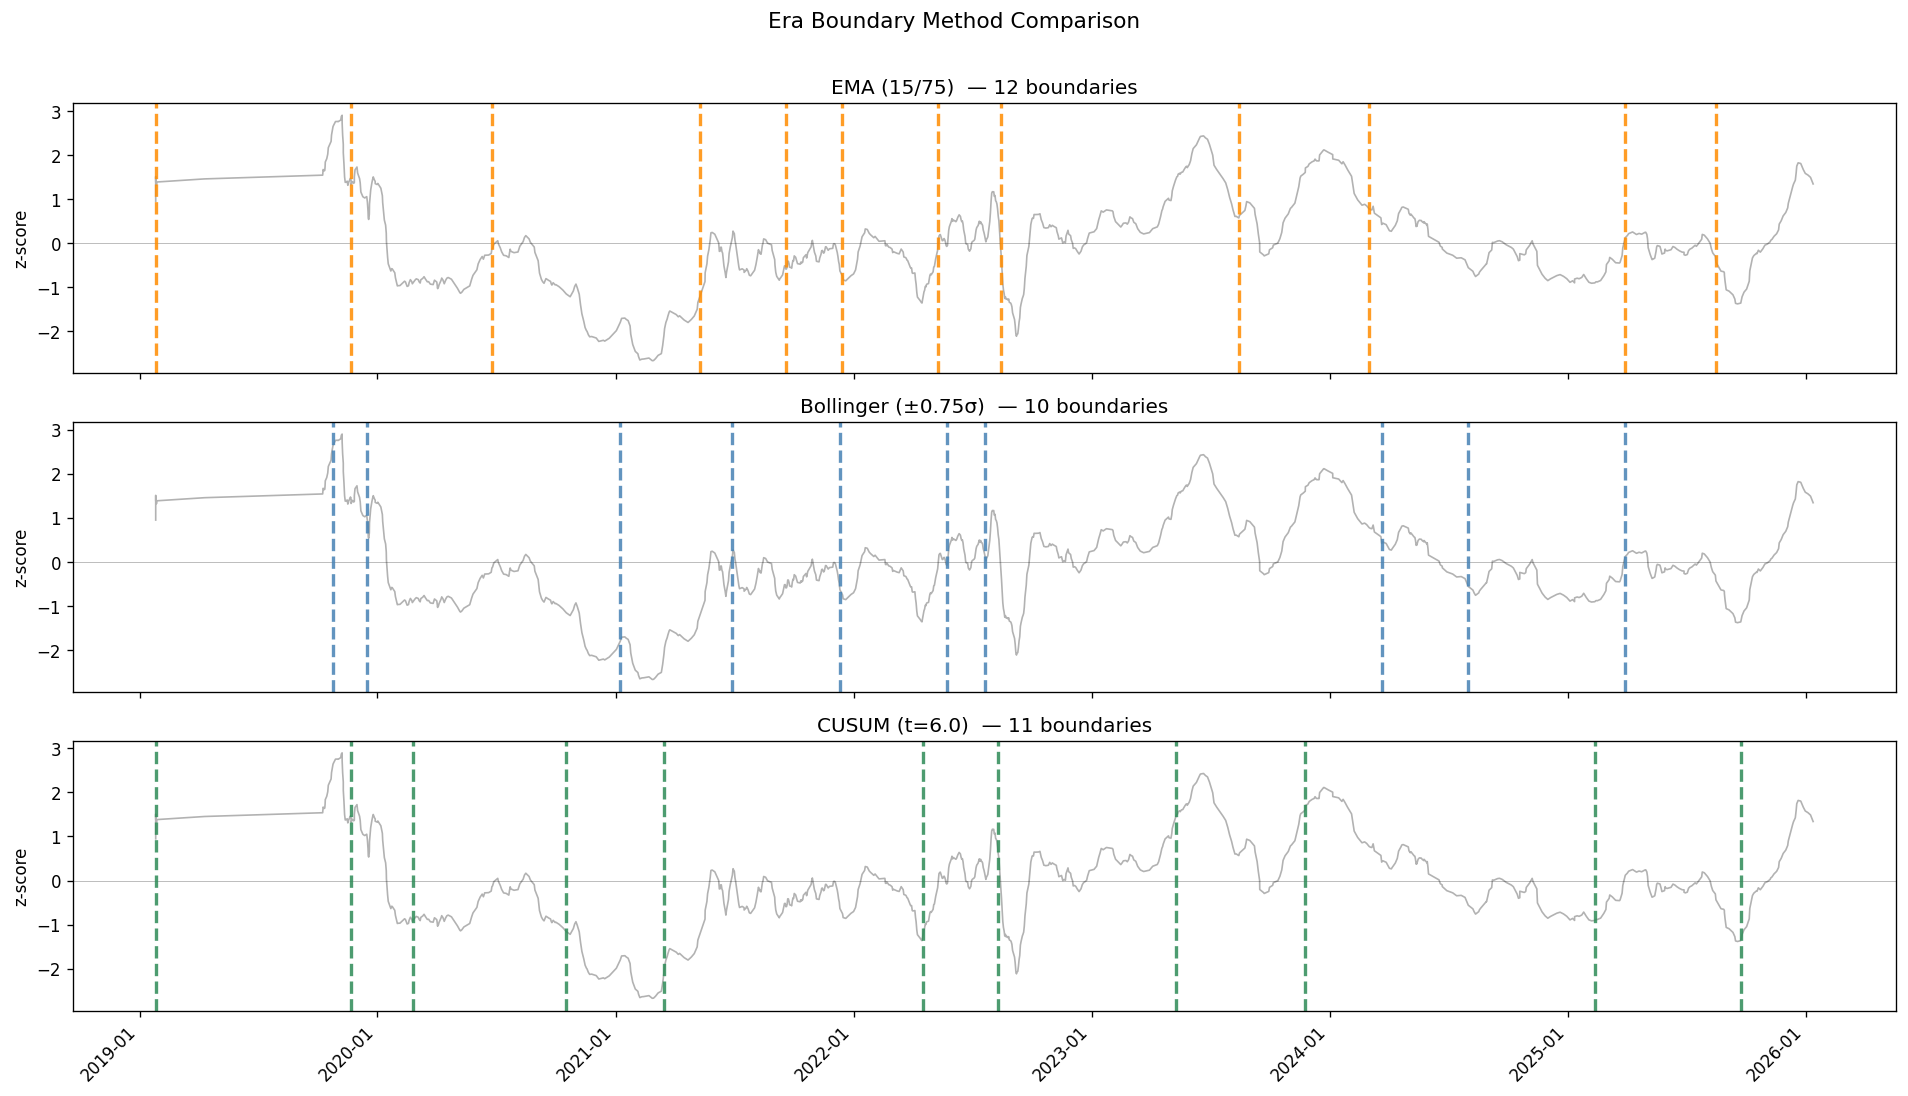


=== Boundary Date Summary ===

Date          EMA (15/75)           Bollinger (±0.75σ)    CUSUM (t=6.0)         
2019-01-25      X                                           X                   
2019-10-24      X                     X                     X                   
2019-11-21      X                     X                     X                   
2019-12-16      X                     X                     X                   
2020-02-24                                                  X                   
2020-06-24      X                                                               
2020-10-16                                                  X                   
2021-01-07                            X                                         
2021-03-15                                                  X                   
2021-05-10      X                                                               
2021-06-28                            X                                      

In [24]:
all_methods = {
    f'EMA ({EMA_FAST}/{EMA_SLOW})': (ema_boundaries, 'darkorange'),
    f'Bollinger (±{BB_N_STD}σ)':    (bb_boundaries,  'steelblue'),
    f'CUSUM (t={CUSUM_THRESHOLD})':  (cusum_boundaries, 'seagreen'),
}

fig, axes = plt.subplots(3, 1, figsize=(16, 9), sharex=True)

for ax, (label, (boundaries, color)) in zip(axes, all_methods.items()):
    ax.plot(mp_dates, mp_smooth, lw=1.0, color='grey', alpha=0.6)
    ax.axhline(0, color='k', lw=0.5, alpha=0.3)
    for b in boundaries:
        ax.axvline(mp_dates[b], color=color, lw=2, ls='--', alpha=0.85)
    ax.set_title(f'{label}  — {len(boundaries)} boundaries')
    ax.set_ylabel('z-score')

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.suptitle('Era Boundary Method Comparison', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('boundary_comparison.png', bbox_inches='tight')
plt.show()

# Summary table
print('\n=== Boundary Date Summary ===\n')
print(f"{'Date':<14}", end='')
for label in all_methods:
    print(f'{label:<22}', end='')
print()

all_dates = sorted(set(
    pd.Timestamp(mp_dates[b]).date()
    for boundaries, _ in all_methods.values()
    for b in boundaries
))
for d in all_dates:
    print(f'{str(d):<14}', end='')
    for boundaries, _ in all_methods.values():
        dates = {pd.Timestamp(mp_dates[b]).date() for b in boundaries}
        nearby = any(abs((d2 - d).days) <= 30 for d2 in dates)
        print(f'{"  X  " if nearby else "     ":<22}', end='')
    print()
